Vehicle Claims Prediction

In [1]:
import pandas as pd
import numpy as np


# Load data

In [ ]:
df = pd.read_csv('labeled_data.csv', sep=',')
test_df = pd.read_csv('unlabeled_data.csv', sep=',')

df.rename(columns={' Genmodel': 'Genmodel', ' Genmodel_ID': 'Genmodel_ID'}, inplace=True)

# Preprocessing / cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37636 entries, 0 to 37635
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 37636 non-null  int64  
 1   Maker              37636 non-null  object 
 2   Genmodel           37636 non-null  object 
 3   Genmodel_ID        37636 non-null  object 
 4   Adv_year           37636 non-null  int64  
 5   Adv_month          37636 non-null  int64  
 6   Color              37636 non-null  object 
 7   Reg_year           37636 non-null  int64  
 8   Bodytype           37636 non-null  object 
 9   Runned_Miles       37636 non-null  int64  
 10  Engin_size         37636 non-null  object 
 11  Gearbox            37636 non-null  object 
 12  Fuel_type          37636 non-null  object 
 13  Price              37636 non-null  int64  
 14  Seat_num           37636 non-null  int64  
 15  Door_num           37636 non-null  int64  
 16  issue              376

In [ ]:
df.head()

# "issue_id" probably encodes "issue" column
# Genmodel_ID encodes "Maker" + "Genmodel"
# "Engin_size" convert to numeric

,ID,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,...,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label
0,11224,Chevrolet,Matiz,16_12,2018,8,Silver,2008,Hatchback,61200,...,Excessive Emissions,0,7,2018-08-07,1,20.6291,1.0,2018-08-07,664.756621,0
1,13673,Ford,Kuga,29_25,2018,5,White,2015,SUV,36579,...,Radiator Leaking,0,9,2018-05-09,1,283.8200,2.0,2018-05-09,11581.844040,0
2,9528,Ford,Fiesta,29_13,2018,7,Red,2010,Hatchback,71000,...,Engine Issue,3,14,2018-07-14,1,500.0000,12.0,2018-07-17,2469.094896,0
3,40424,DS,3,21_1,2018,3,Black,2017,Hatchback,6449,...,Flat Tyres,0,25,2018-03-25,2,44.0374,2.0,2018-03-25,12785.925740,0
4,10711,Ford,S-Max,29_31,2018,5,White,2014,MPV,63751,...,Windscreen Crack,0,14,2018-05-14,1,27.0794,1.0,2018-05-14,11203.608000,0


In [ ]:
df.Fuel_type.unique()

array(['Petrol', 'Diesel', 'still_Diesel_but_you_found_an_easteregg',
       'Hybrid  Petrol/Electric', 'Bi Fuel', 'Petrol Hybrid', 'Hydrogen',
       'Hybrid  Petrol/Electric Plug-in', 'Petrol Ethanol', 'Electric',
       'Hybrid  Diesel/Electric', 'Petrol Plug-in Hybrid'], dtype=object)

In [ ]:
df.Gearbox.unique()

array(['Manual', 'Automatic', 'Hybrid', 'Semi-Automatic'], dtype=object)

In [ ]:
# "ID" column has no prediction value
df = df.drop(columns = ['ID'], axis=1)


In [ ]:
df.describe()

# Coulmns "Runned_Miles"(-19826), "Door_num" (0), "repair_cost" (-44470) have impossible values
# Adv year, Adv month and Adv day schould be combined into 1 column (with date type)
# Get rid of "Price", "repair costs", "repair hours", "Runned_Miles" outliers - extreme values

,Adv_year,Adv_month,Reg_year,Runned_Miles,Price,Seat_num,Door_num,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value,Label
count,37636.000000,37636.000000,37636.000000,37636.000000,3.763600e+04,37636.000000,37636.000000,37636.000000,37636.000000,37636.000000,37636.000000,37636.000000,3.763600e+04,37636.000000
mean,2006.104900,5.682352,2012.382639,48194.858752,1.184000e+04,5.114040,4.345653,0.499681,14.485997,1.281566,309.050330,53.423268,1.124802e+04,0.109868
std,147.533118,2.072882,4.567317,39475.087212,3.404482e+04,1.640498,1.115353,1.133672,8.089406,0.545602,1547.474509,718.339249,3.234256e+04,0.312730
min,202.000000,1.000000,1960.000000,-19826.000000,1.250000e+02,2.000000,0.000000,0.000000,1.000000,1.000000,-44470.000000,0.500000,1.123048e+02,0.000000
25%,2018.000000,4.000000,2009.000000,15389.750000,3.500000e+03,5.000000,3.000000,0.000000,7.000000,1.000000,25.157000,1.000000,3.327641e+03,0.000000
50%,2018.000000,5.000000,2013.000000,39249.000000,7.343500e+03,5.000000,5.000000,0.000000,14.000000,1.000000,84.296500,2.000000,6.975036e+03,0.000000
75%,2018.000000,7.000000,2016.000000,74204.500000,1.199000e+04,5.000000,5.000000,0.000000,22.000000,1.000000,243.242500,6.000000,1.138671e+04,0.000000
max,2021.000000,13.000000,2019.000000,900000.000000,2.599990e+06,20.000000,7.000000,5.000000,28.000000,4.000000,98690.116330,73134.610090,2.469993e+06,1.000000


In [ ]:
df[df.Runned_Miles < 0]

,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,...,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label
36,Dacia,Duster,22_1,2018,3,Silver,2014,SUV,-9502,1.5L,...,Transmission Issue,3,6,2018-03-06,1,223.099000,8.0,2018-03-08,6667.253329,0
334,Ford,Mondeo,29_27,2018,7,Black,2014,Estate,-11488,2.0L,...,Excessive Emissions,0,11,2018-07-11,1,26.294600,1.0,2018-07-11,6648.339016,1
2128,Ford,Mustang,29_28,2018,8,Red,2018,Coupe,-18477,4.7L,...,Brake Pads Worn,0,26,2018-08-26,1,47.997500,2.0,2018-08-26,15188.006910,0
2517,Ford,Transit Custom,29_38,2021,1,Black,2019,Combi Van,-848,2.0L,...,Excessive Emissions,0,20,2021-01-20,1,-54.549200,1.0,2021-01-20,36466.791630,1
2640,Ford,Mondeo,29_27,2018,8,Blue,2014,Hatchback,-9889,2.0L,...,Tyre Alignment,0,25,2018-08-25,1,10.649400,0.5,2018-08-25,6172.416735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37115,Ford,Focus,29_14,2018,8,Silver,2002,Estate,-19826,1.8L,...,Flat Tyres,0,8,2018-08-08,1,87.254186,1.0,2018-08-08,1409.741316,1
37252,Fiat,Panda,28_18,2018,1,Orange,2006,Hatchback,-6992,1.1L,...,Electrical Issue,1,11,2018-01-11,1,40.990000,2.0,2018-01-11,943.224040,1
37313,Ford,Ka,29_23,2018,8,Red,2007,Hatchback,-2605,1.3L,...,Brake Pads Worn,0,7,2018-08-07,1,40.642500,2.0,2018-08-07,1220.795446,0
37459,Ford,Mondeo,29_27,2018,3,Silver,2015,Estate,-8875,1.5L,...,Starter Motor Issue,0,22,2018-03-22,1,219.950000,3.0,2018-03-22,15190.267130,1


In [ ]:
# Replace non-positive values by positive

df["Runned_Miles"] = np.where(df.Runned_Miles > 0,df.Runned_Miles, df.Runned_Miles * (-1))

df["repair_cost"] = np.where(df.repair_cost > 0, df.repair_cost, df.repair_cost * (-1))

df["Door_num"] = np.where(df.Door_num > 0, df.Door_num, 1)

In [ ]:
# "Adv_year" has impossible values - 202

df['Adv_year'].unique()

array([2018, 2017, 2021,  202, 2019, 2016, 2015, 2014, 2013, 2012])

In [ ]:
# Replace "Adv_year" 202 by 2020

df.loc[df['Adv_year'] == 202] = 2020
df['Adv_year'].unique()

array([2018, 2017, 2021, 2020, 2019, 2016, 2015, 2014, 2013, 2012])

In [ ]:
# "Adv_month" has impossible values - 13 and 2020

df['Adv_month'].unique()
df[df['Adv_month'].isin([13, 2020])]



,Maker,Genmodel,Genmodel_ID,Adv_year,Adv_month,Color,Reg_year,Bodytype,Runned_Miles,Engin_size,...,issue,issue_id,Adv_day,breakdown_date,repair_complexity,repair_cost,repair_hours,repair_date,value,Label
287,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
336,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
357,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
420,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
465,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36579,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
36640,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
36704,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020
37219,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,...,2020,2020,2020,2020,2020,2020.0,2020.0,2020,2020.0,2020


In [ ]:
# Delete these corrupted rows

df = df[df['Adv_month'] != 2020]
df.loc[df['Adv_month'] == 13, 'Adv_month'] = 12
df['Adv_month'].unique()

array([ 8,  5,  7,  3,  9,  6,  4,  1, 11, 10,  2, 12])

In [ ]:
df['Color'].unique()

# Yellow = Gelb

array(['Silver', 'White', 'Red', 'Black', 'Orange', 'Blue', 'Grey',
       'Green', 'Gelb', 'Purple', 'Yellow', 'Brown', 'Pink', 'Beige',
       'Bronze', 'Gold', 'Multicolour', 'Turquoise', 'Burgundy',
       'Magenta', 'Maroon', 'Indigo'], dtype=object)

In [ ]:
# Replce "Gelb" color with "Yellow"

df.loc[df['Color'] == 'Gelb', 'Color'] = 'Yellow'
df['Color'].unique()

array(['Silver', 'White', 'Red', 'Black', 'Orange', 'Blue', 'Grey',
       'Green', 'Yellow', 'Purple', 'Brown', 'Pink', 'Beige', 'Bronze',
       'Gold', 'Multicolour', 'Turquoise', 'Burgundy', 'Magenta',
       'Maroon', 'Indigo'], dtype=object)

In [ ]:
# Checking for multicollimearity

# Choose only numerical values 
is_number = np.vectorize(lambda x: np.issubdtype(x, np.number))
is_number(df.dtypes)

# Correlation matrix
df.loc[:, is_number(df.dtypes)].corr()

,Adv_year,Adv_month,Reg_year,Runned_Miles,Price,Seat_num,Door_num,issue_id,Adv_day,repair_complexity,repair_cost,repair_hours,value,Label
Adv_year,1.000000,-0.218954,0.386748,-0.221319,0.013705,-0.018312,0.078644,0.000441,0.003150,-0.039418,0.016195,0.014174,0.013703,-0.044525
Adv_month,-0.218954,1.000000,-0.065383,0.052568,-0.016462,-0.009780,-0.025307,-0.001653,-0.001286,-0.032194,-0.011410,-0.003393,-0.016462,-0.054201
Reg_year,0.386748,-0.065383,1.000000,-0.731997,0.160177,0.033281,0.082330,-0.001638,-0.006825,0.001914,0.093910,0.029675,0.160176,0.000848
Runned_Miles,-0.221319,0.052568,-0.731997,1.000000,-0.209407,0.012405,0.088357,-0.000185,0.008260,-0.092022,-0.111200,-0.030350,-0.209407,-0.015625
Price,0.013705,-0.016462,0.160177,-0.209407,1.000000,-0.037950,-0.199561,-0.005717,-0.005257,0.317726,0.344939,0.064854,1.000000,0.027886
Seat_num,-0.018312,-0.009780,0.033281,0.012405,-0.037950,1.000000,0.057082,0.010611,-0.010700,0.011560,-0.024329,-0.014130,-0.037949,0.160500
Door_num,0.078644,-0.025307,0.082330,0.088357,-0.199561,0.057082,1.000000,-0.006024,0.008196,-0.205954,-0.097799,-0.023052,-0.199561,-0.073044
issue_id,0.000441,-0.001653,-0.001638,-0.000185,-0.005717,0.010611,-0.006024,1.000000,0.005775,0.009465,0.116416,0.040801,-0.005718,0.004514
Adv_day,0.003150,-0.001286,-0.006825,0.008260,-0.005257,-0.010700,0.008196,0.005775,1.000000,-0.006915,-0.002456,-0.000919,-0.005256,0.000763
repair_complexity,-0.039418,-0.032194,0.001914,-0.092022,0.317726,0.011560,-0.205954,0.009465,-0.006915,1.000000,0.179916,0.041671,0.317728,-0.025468


<Axes: >

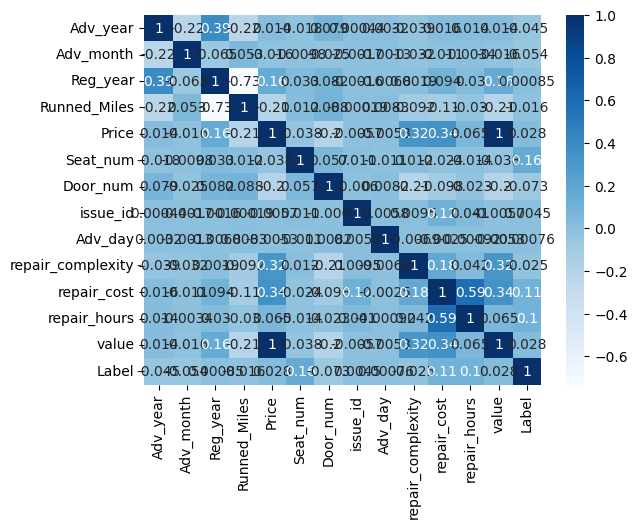

In [ ]:
# Visualization of Correlation matrix

import seaborn as sb
corr = df.loc[:, is_number(df.dtypes)].corr()
sb.heatmap(corr, cmap="Blues", annot=True)

In [ ]:
# Value and Price colums are identical - Drop column "value"
df = df.drop(columns="value")

# Repair comlexity and Price (corr = 0.3), Repair cost and Price (corr = 0.25) are strongly correlated

# Train/validation split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=['Label'], axis=1)
y = df['Label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
len(X_train), len(X_val)

(29908, 7478)

# Identification and preprocessing of categorical and numerical features

In [ ]:
categorical_features = X_train.select_dtypes(include=['object', 'int64']).columns
numerical_features = X_train.select_dtypes(include=['float64']).columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    #('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 Index(['repair_cost', 'repair_hours'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Maker', 'Genmodel', 'Genmodel_ID', 'Adv_year', 'Adv_month', 'Color',
       'Reg_year', 'Bodytype', 'Runned_Miles', 'Engin_size', 'Gearbox',
       'Fuel_type', 'Price', 'Seat_num', 'Door_num', 'issue', 'issue_id',
       'Adv_day', 'breakdown_date', 'repair_complexity', 'repair_date'],
      dtype='object'))])

In [ ]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


# Handle class imbalance

In [ ]:
from imblearn.over_sampling import SMOTE

from collections import Counter
import seaborn as sns

Class distribution before handling imbalance: Counter({0: 26613, 1: 3295})


<Axes: xlabel='Label', ylabel='count'>

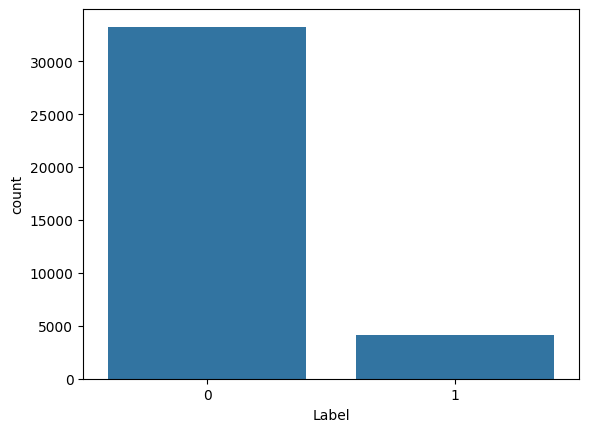

In [ ]:
print("Class distribution before handling imbalance:", Counter(y_train))
sns.countplot(x = 'Label' , data = df)

Class distribution after SMOTE: Counter({1: 26613, 0: 26613})


<Axes: xlabel='Label', ylabel='count'>

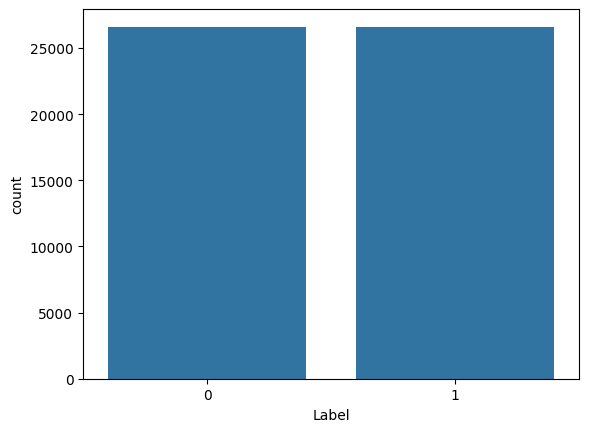

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(preprocessor.fit_transform(X_train), y_train)

print("Class distribution after SMOTE:", Counter(y_train_resampled))
sns.countplot(x = 'Label' , data = pd.DataFrame(y_train_resampled, columns=['Label']))

Class distribution after ADASYN: Counter({0: 26613, 1: 26283})


<Axes: xlabel='Label', ylabel='count'>

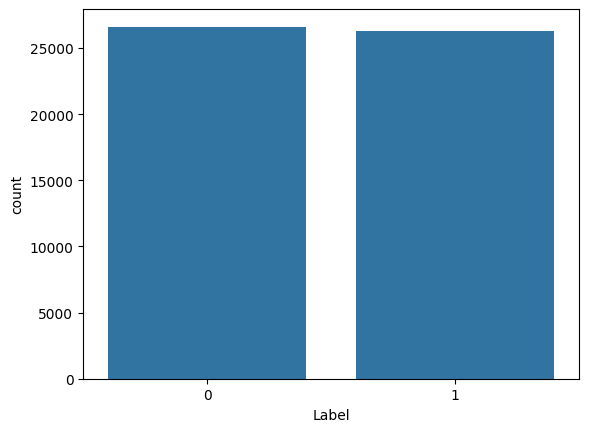

In [ ]:
# try ADASYN instead of SMOTE
from imblearn.over_sampling import ADASYN
adasyn = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(preprocessor.fit_transform(X_train), y_train)

print("Class distribution after ADASYN:", Counter(y_train_resampled))
sns.countplot(x = 'Label' , data = pd.DataFrame(y_train_resampled, columns=['Label']))

Class distribution after KMeansSMOTE: Counter({1: 26614, 0: 26613})


<Axes: xlabel='Label', ylabel='count'>

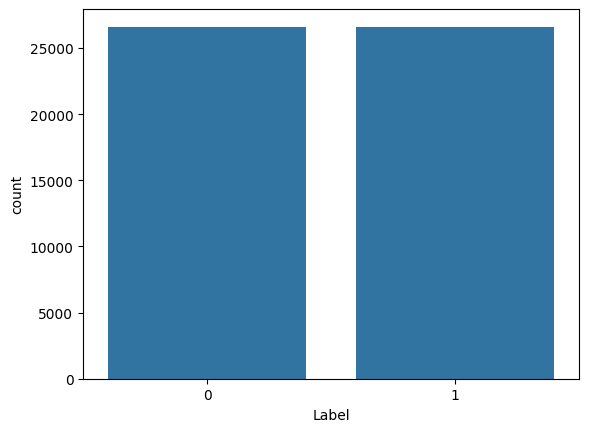

In [ ]:
# try K-means SMOTE now
from imblearn.over_sampling import KMeansSMOTE
kmeans_smote = KMeansSMOTE(cluster_balance_threshold=0.1, random_state=4, sampling_strategy='auto')
X_train_resampled, y_train_resampled = kmeans_smote.fit_resample(preprocessor.fit_transform(X_train), y_train)

print("Class distribution after KMeansSMOTE:", Counter(y_train_resampled))
sns.countplot(x = 'Label' , data = pd.DataFrame(y_train_resampled, columns=['Label']))

# Define the model evaluation function

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

In [ ]:
def build_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Trains a given model, makes predictions on the training and test sets,
    and calculates and displays the confusion matrix, various evaluation metrics,
    and ROC/PR curves with AUC.  Allows setting a custom threshold.
    """
    model.fit(X_train, y_train)
    y_pred_train_proba = None
    y_pred_test_proba = None

    if hasattr(model, "predict_proba"):
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        y_pred_proba_test = model.predict_proba(X_test)[:, 1]

    # Use threshold to make predictions
    y_pred_train = (y_pred_proba_train >= threshold).astype(int) if y_pred_proba_train is not None else model.predict(X_train_processed)
    y_pred_test = (y_pred_proba_test >= threshold).astype(int) if y_pred_proba_test is not None else model.predict(X_test_processed)

    print(f"--- {model_name} Evaluation (Threshold = {threshold:.2f})---")

    for name, y_true, y_pred, y_pred_proba in [("Training Set", y_train, y_pred_train, y_pred_proba_train),
                                                 ("Validation Set", y_test, y_pred_test, y_pred_proba_test)]:
        print(f"\n--- {name} ---")
        cm = confusion_matrix(y_true, y_pred)
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        TN, FP, FN, TP = cm.ravel()
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        TNR = TN / (TN + FP) if (TN + FP) > 0 else 0
        FNR = FN / (FN + TP) if (FN + TP) > 0 else 0

        print("Confusion Matrix:\n", cm)
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall (TPR or Sensitivity): {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"TPR (True Positive Rate): {TPR:.4f}")
        print(f"FPR (False Positive Rate): {FPR:.4f}")
        print(f"TNR (True Negative Rate): {TNR:.4f}")
        print(f"FNR (False Negative Rate): {FNR:.4f}")

        if y_pred_proba is not None:
            # ROC Curve
            fpr, tpr, thresholds_roc = roc_curve(y_true, y_pred_proba)
            roc_auc = roc_auc_score(y_true, y_pred_proba)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve - {model_name} ({name})')
            plt.legend(loc='lower right')
            plt.show()

            # PR Curve
            precision_pr, recall_pr, thresholds_pr = precision_recall_curve(y_true, y_pred_proba)
            auc_pr = auc(recall_pr, precision_pr)
            plt.figure(figsize=(8, 6))
            plt.plot(recall_pr, precision_pr, color='blue', lw=2, label=f'PR curve (AUC = {auc_pr:.2f})')
            plt.plot([0, 1], [y_true.mean(), y_true.mean()], color='gray', lw=2, linestyle='--', label='Random classifier')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'PR Curve - {model_name} ({name})')
            plt.legend(loc='upper right')
            plt.show()

    print("-" * 30)
    return model


In [ ]:
X_val_processed = preprocessor.transform(X_val)

# Logistic Regression (No regularization)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


--- Logistic Regression (No regularization) Evaluation (Threshold = 0.50)---

--- Training Set ---
Confusion Matrix:
 [[25611  1002]
 [  859 25755]]
Accuracy: 0.9650
Precision: 0.9626
Recall (TPR or Sensitivity): 0.9677
F1 Score: 0.9651
TPR (True Positive Rate): 0.9677
FPR (False Positive Rate): 0.0377
TNR (True Negative Rate): 0.9623
FNR (False Negative Rate): 0.0323


c:\Users\kosty\anaconda3\envs\redi-labs\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


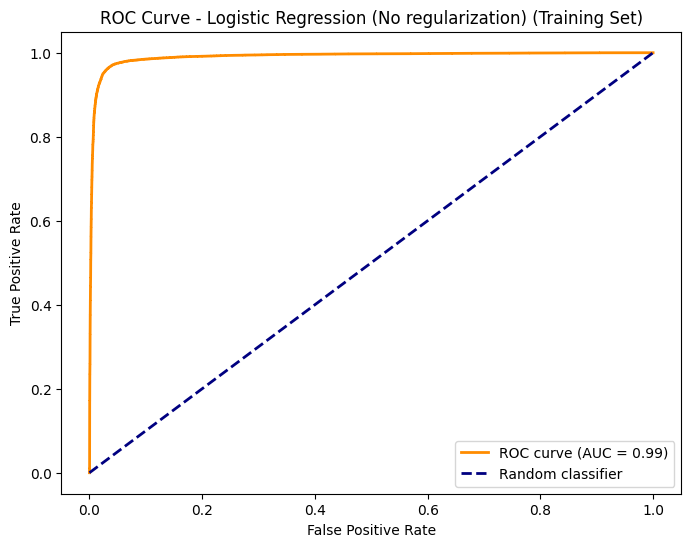

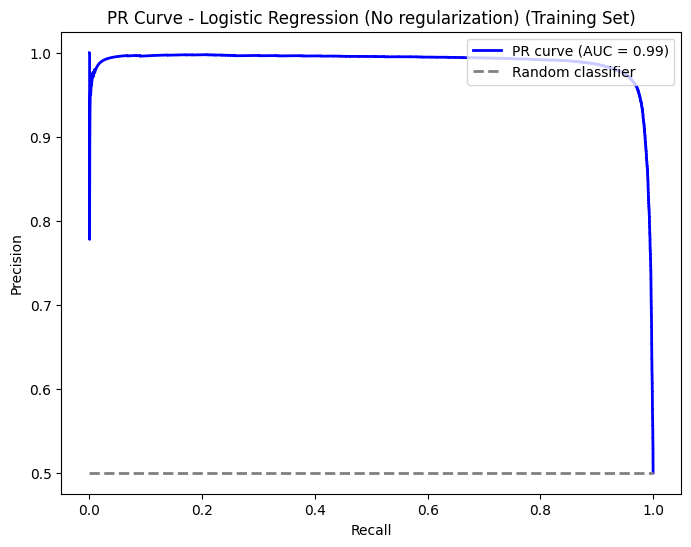


--- Validation Set ---
Confusion Matrix:
 [[6092  562]
 [ 480  344]]
Accuracy: 0.8607
Precision: 0.3797
Recall (TPR or Sensitivity): 0.4175
F1 Score: 0.3977
TPR (True Positive Rate): 0.4175
FPR (False Positive Rate): 0.0845
TNR (True Negative Rate): 0.9155
FNR (False Negative Rate): 0.5825


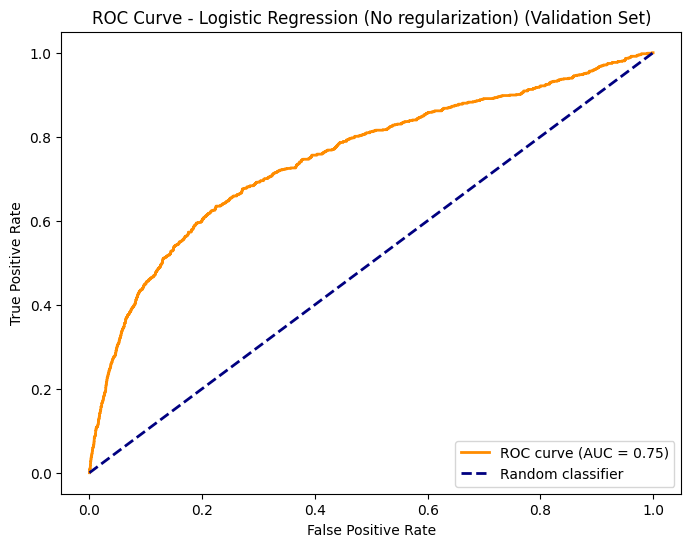

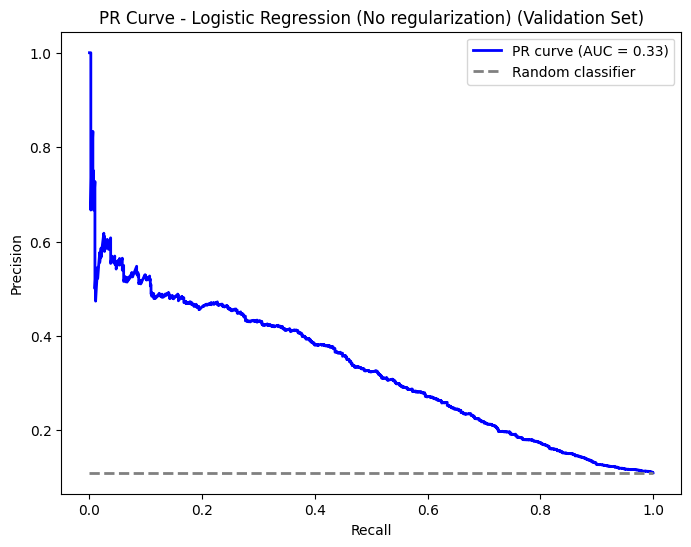

------------------------------


In [ ]:
logistic_regression = Pipeline(steps=[('classifier', LogisticRegression(penalty=None, solver='lbfgs', random_state=42))])
logistic_regression_model = build_and_evaluate_model(logistic_regression, X_train_resampled, y_train_resampled, X_val_processed, y_val, "Logistic Regression (No regularization)")

# Logistic Regrression (with L2)

--- Logistic Regression (L2) Evaluation (Threshold = 0.50)---

--- Training Set ---
Confusion Matrix:
 [[25072  1541]
 [ 1206 25408]]
Accuracy: 0.9484
Precision: 0.9428
Recall (TPR or Sensitivity): 0.9547
F1 Score: 0.9487
TPR (True Positive Rate): 0.9547
FPR (False Positive Rate): 0.0579
TNR (True Negative Rate): 0.9421
FNR (False Negative Rate): 0.0453


c:\Users\kosty\anaconda3\envs\redi-labs\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


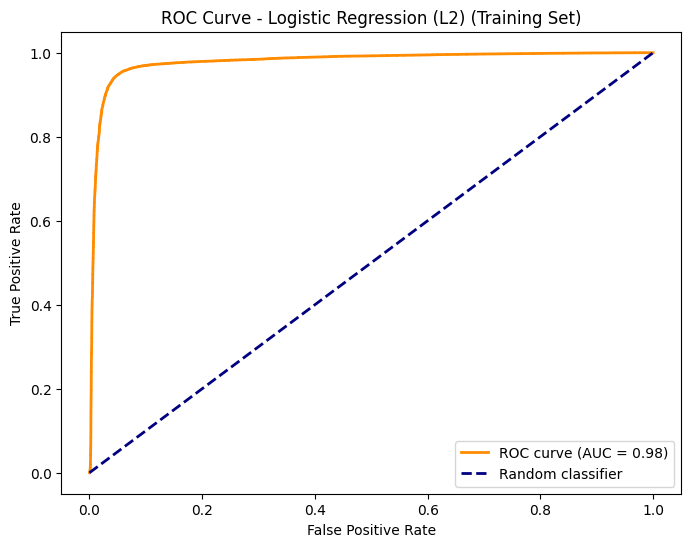

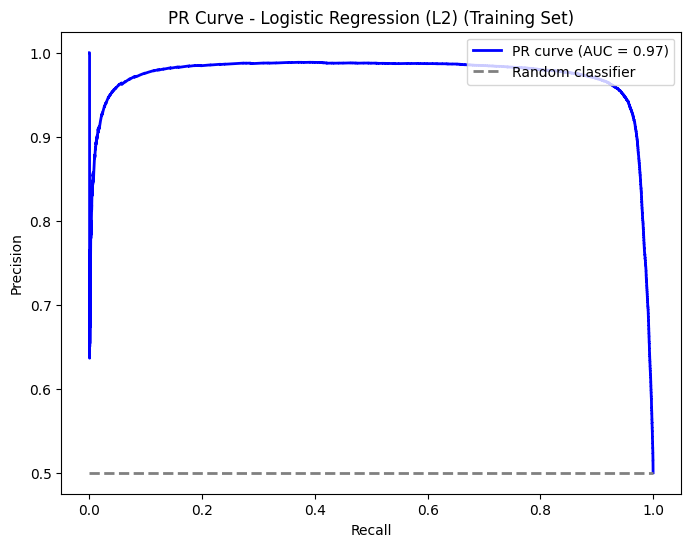


--- Validation Set ---
Confusion Matrix:
 [[6107  547]
 [ 413  411]]
Accuracy: 0.8716
Precision: 0.4290
Recall (TPR or Sensitivity): 0.4988
F1 Score: 0.4613
TPR (True Positive Rate): 0.4988
FPR (False Positive Rate): 0.0822
TNR (True Negative Rate): 0.9178
FNR (False Negative Rate): 0.5012


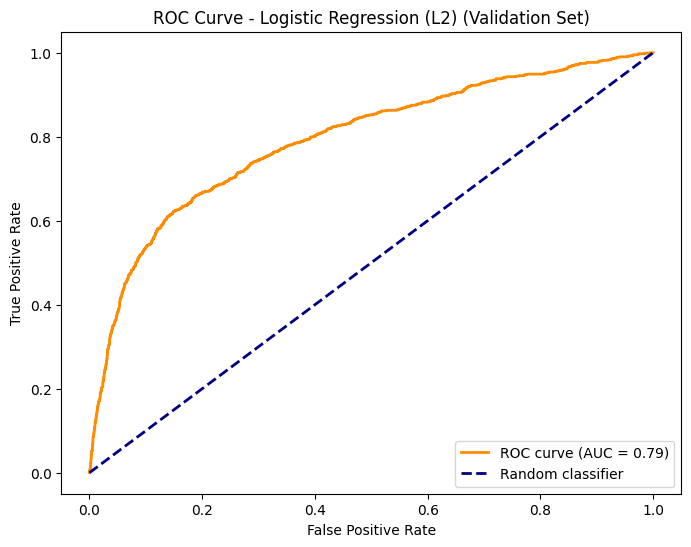

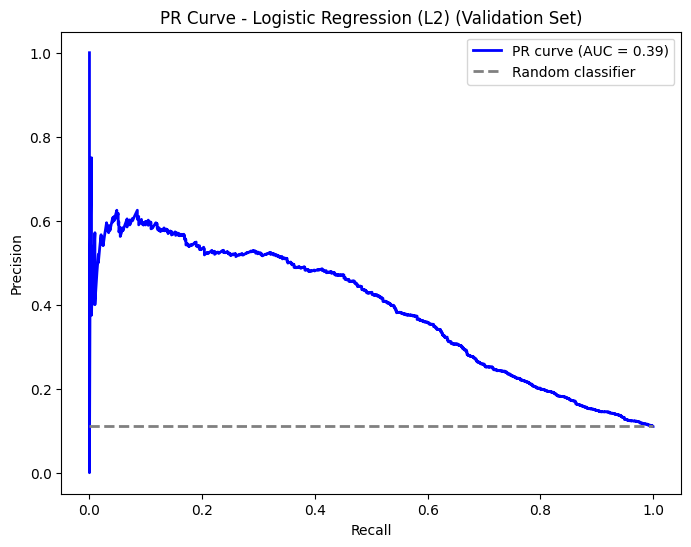

------------------------------


In [ ]:
logistic_regression_l2 = Pipeline(steps=[('classifier', LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, C=1.0))])
logistic_regression_l2_model = build_and_evaluate_model(logistic_regression_l2, X_train_resampled, y_train_resampled, X_val_processed, y_val, "Logistic Regression (L2)")


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

--- Random Forest Evaluation (Threshold = 0.50)---

--- Training Set ---
Confusion Matrix:
 [[26604     9]
 [   81 26533]]
Accuracy: 0.9983
Precision: 0.9997
Recall (TPR or Sensitivity): 0.9970
F1 Score: 0.9983
TPR (True Positive Rate): 0.9970
FPR (False Positive Rate): 0.0003
TNR (True Negative Rate): 0.9997
FNR (False Negative Rate): 0.0030


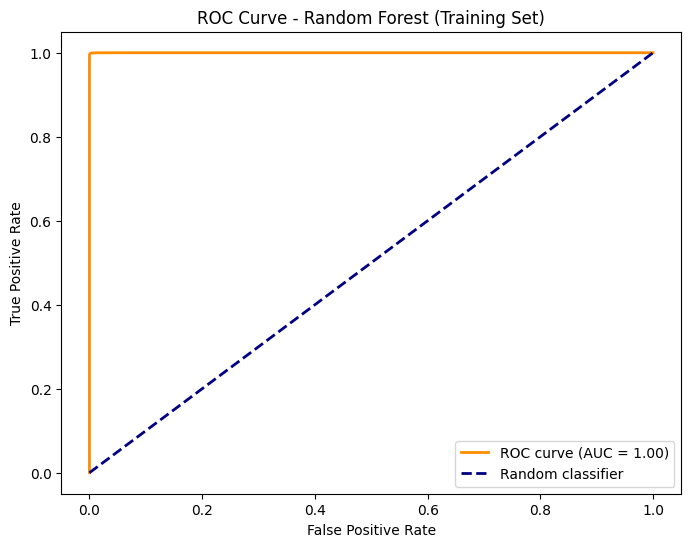

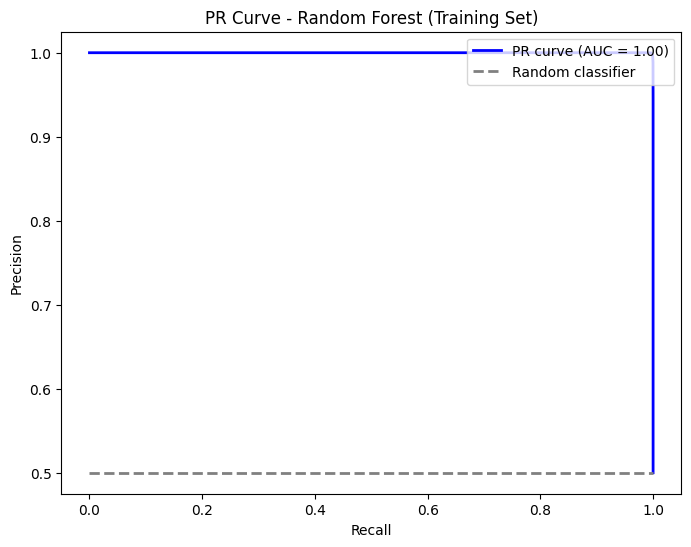


--- Validation Set ---
Confusion Matrix:
 [[6530  124]
 [ 670  154]]
Accuracy: 0.8938
Precision: 0.5540
Recall (TPR or Sensitivity): 0.1869
F1 Score: 0.2795
TPR (True Positive Rate): 0.1869
FPR (False Positive Rate): 0.0186
TNR (True Negative Rate): 0.9814
FNR (False Negative Rate): 0.8131


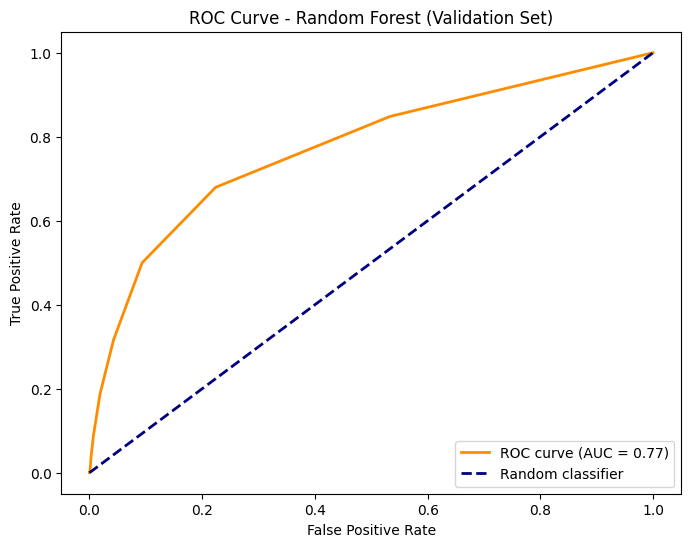

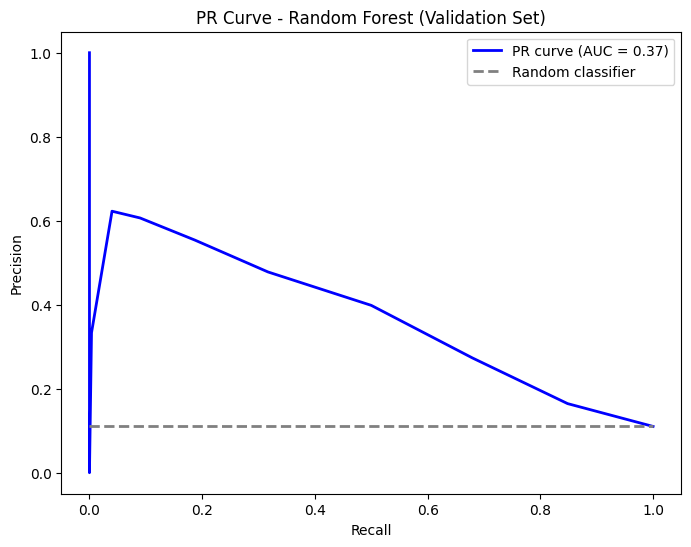

------------------------------


In [ ]:
random_forest = Pipeline(steps=[('classifier', RandomForestClassifier(random_state=42, n_estimators=10))])
random_forest_model = build_and_evaluate_model(random_forest, X_train_resampled, y_train_resampled, X_val_processed, y_val, "Random Forest")


# Prediction on the Test Data (using the best model)

In [ ]:
test_df.rename(columns={' Genmodel': 'Genmodel', ' Genmodel_ID': 'Genmodel_ID'}, inplace=True)

In [ ]:
X_test_processed = preprocessor.transform(test_df)

test_predictions = random_forest_model.predict(X_test_processed)
prediction_df = pd.DataFrame({'ID': test_df['ID'], 'Label': test_predictions})
prediction_df.to_csv('prediction.csv', index=False)
print("\n'prediction.csv' has been created.")
prediction_df


'prediction.csv' has been created.


,ID,Label
0,29455,0
1,41446,0
2,42116,0
3,32619,0
4,51078,0
...,...,...
16125,16798,0
16126,34307,0
16127,13753,0
16128,46897,0
